# DortDB Benchmarks: UniBench

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

LOG_PATH = '../../dist/logs/'
GRAPH_PATH = '../../dist/graphs/'
os.makedirs(GRAPH_PATH, exist_ok=True)


dort = pd.concat([
    pd.read_json(f'{LOG_PATH}{path}.log', lines=True) for path in [
        'unibench_dortdb_1-2-3-4-5-6-7-8-9', 'unibench_dortdb_10', 'unibench_dortdb_11'
    ]
], ignore_index=True)
dort_sample = pd.read_json(f'{LOG_PATH}dortdb_sample.log', lines=True)
# dort_old = pd.read_json(f'{LOG_PATH}dortdb_old.log', lines=True)
arango = pd.read_json(f'{LOG_PATH}arango.log', lines=True)
arango_sample = pd.read_json(f'{LOG_PATH}arango_sample.log', lines=True)
orient = pd.read_json(f'{LOG_PATH}orient.log', lines=True)

for df in [arango, arango_sample, orient]:
    df['query'] = df['query'].str.slice(0, 3)

for df in [dort, dort_sample]:
    for row in df.itertuples():
        if isinstance(row.query, str):
            df.at[row.Index, 'query'] = row.query[:-4]
        elif isinstance(row.detail, dict):
            df.at[row.Index, 'query'] = row.detail.get('q', '')[:-4]


# colors = {
#     'DortDB': '#005cbb',
#     'DortDB (sample)': '#abc7ff',
#     'ArangoDB': '#5b6f3e',
#     'ArangoDB (sample)': '#dddf72',
#     'OrientDB': '#ee521b',
# }
colors = {
    'DortDB': '#e5ccff',
    'DortDB (old)': "#b292d4",
    'DortDB (sample)': "#9975be",
    'ArangoDB': '#9ac7bf',
    'ArangoDB (sample)': "#4c8f82",
    'OrientDB': '#f19c99',
}
labels = {
    'dort': 'DortDB',
    'dort_old': 'DortDB (old)',
    'dort_sample': 'DortDB (sample)',
    'arango': 'ArangoDB',
    'arango_sample': 'ArangoDB (sample)',
    'orient': 'OrientDB',
}

## Importing data

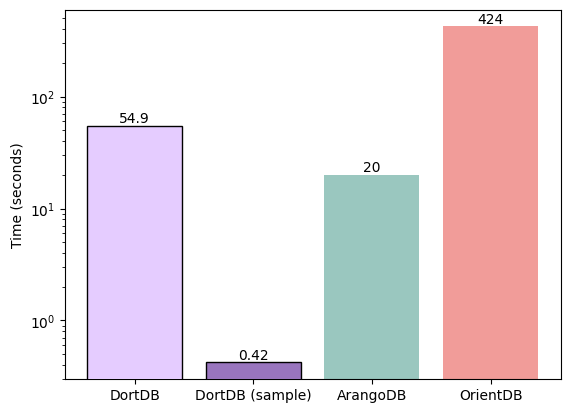

In [2]:
dort_sample_ds = dort_sample[dort_sample['name'] == 'parseUnibenchData']
dort_sample_indices = dort_sample[dort_sample['name'] == 'registerIndices']
dort_ds = dort[dort['name'] == 'parseUnibenchData']
dort_indices = dort[dort['name'] == 'registerIndices']


# Example: plot the number of rows in each dataframe
data = {
  'DortDB': (dort_ds['duration'].agg('mean') + dort_indices['duration'].agg('mean')) / 1000,
  'DortDB (sample)': (dort_sample_ds['duration'].agg('mean') + dort_sample_indices['duration'].agg('mean')) / 1000,
  'ArangoDB': 20,
  'OrientDB': 424
}

for i, (label, value) in enumerate(data.items()):
  plt.text(i, value, f'{value:.3g}', ha='center', va='bottom', fontsize=10)

ax = plt.bar(data.keys(), data.values(), color=[colors[label] for label in data.keys()])
for bar in ax.patches[:2]:
  bar.set_edgecolor('black')
  bar.set_zorder(3)

plt.ylabel('Time (seconds)')
plt.yscale('log')
plt.savefig(f'{GRAPH_PATH}unibench-init.pdf', bbox_inches='tight')
plt.show()

## Memory usage

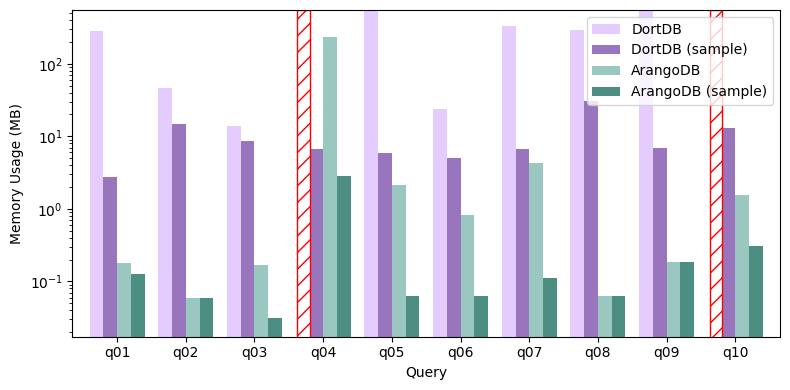

In [20]:
dort_memory_before = dort[dort['msg'] == 'Memory usage before running query']
dort_memory_after = dort[dort['msg'] == 'Memory usage after running query']
dort_memory = dort_memory_after.groupby('query').agg({'heapUsed': 'mean'}) - dort_memory_before.groupby('query').agg({'heapUsed': 'mean'})

dort_sample_memory_before = dort_sample[dort_sample['msg'] == 'Memory usage before running query']
dort_sample_memory_after = dort_sample[dort_sample['msg'] == 'Memory usage after running query']
dort_sample_memory = dort_sample_memory_after.groupby('query').agg({'heapUsed': 'mean'}) - dort_sample_memory_before.groupby('query').agg({'heapUsed': 'mean'})

arango_memory = arango[arango['msg'] == 'Executed query successfully'].groupby('query').agg({'memory': 'mean'})

arango_sample_memory = arango_sample[arango_sample['msg'] == 'Executed query successfully'].groupby('query').agg({'memory': 'mean'})

# join the dataframes by query
memory = pd.concat([
    dort_memory.rename(columns={'heapUsed': 'DortDB'}),
    dort_sample_memory.rename(columns={'heapUsed': 'DortDB (sample)'}),
    arango_memory.rename(columns={'memory': 'ArangoDB'}),
    arango_sample_memory.rename(columns={'memory': 'ArangoDB (sample)'}),
], axis=1)
# Convert bytes to MB for better readability
memory_mb = memory / (1024 * 1024)

# Sort queries before plotting
memory_mb.sort_index(inplace=True)
ax = memory_mb.plot(kind='bar', width=0.8, color=[colors[col] for col in memory_mb.columns])
plt.gcf().set_size_inches(8, 4)

# Highlight missing values (out of memory) with a hatch or annotation
for i, row in enumerate(memory_mb.itertuples()):
    for j, val in enumerate(row[1:]):
        if pd.isna(val):
            ax.bar(i - 0.375 + j * (0.8 / len(memory_mb.columns)), 550, 
                   width=0.75 / len(memory_mb.columns), 
                   color='white', edgecolor='red', hatch='//', align='edge')

ax.set_ylabel('Memory Usage (MB)')
ax.set_xlabel('Query')
ax.set_yscale('log')
ax.legend(loc='upper right')
ax.set_ylim(None, 550)
ax.tick_params('x', rotation=0)
plt.tight_layout()
# plt.savefig('graphs/unibench-memory.pdf', bbox_inches='tight')
plt.show()



## Execution time

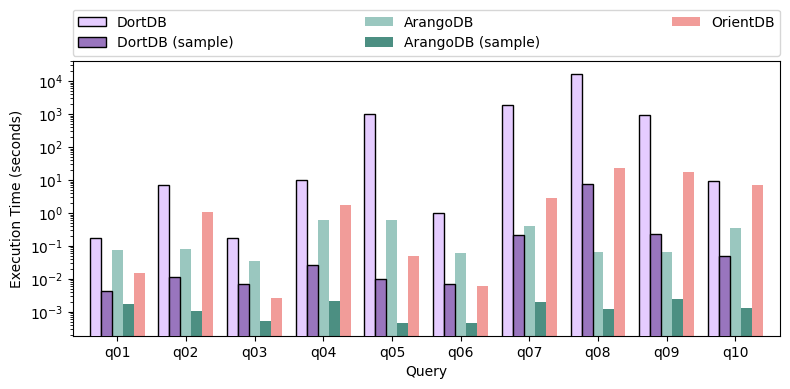

In [ ]:
for (df, label) in zip([dort, dort_sample], ['DortDB', 'DortDB (sample)']):
    for q in df['query'].dropna().unique():
        mask_q = df['query'] == q
        # detect any non-warmup runs (either via column or detail dict)
        warmed_detail = df.loc[mask_q, 'detail'].apply(lambda d: isinstance(d, dict) and d.get('isWarmup') == False)
        if (warmed_detail).any():
            # print(f'Dropping warmup runs for query {q} in dataframe {label}')
            # drop warmup runs for this query (column or detail)
            warmup_detail = df['detail'].apply(lambda d: isinstance(d, dict) and d.get('isWarmup') == True)
            warmup_mask = mask_q & warmup_detail
            df.drop(df[warmup_mask].index, inplace=True)

skipped_queries = ['q04_naive']

dort_extime = dort[(dort['msg'] == 'Performance entry') & ~dort['query'].isna() & ~dort['query'].isin(skipped_queries)].groupby('query').agg({'duration': 'mean'}) / 1000
dort_sample_extime = dort_sample[(dort_sample['msg'] == 'Performance entry') & ~dort_sample['query'].isna() & ~dort_sample['query'].isin(skipped_queries)].groupby('query').agg({'duration': 'mean'}) / 1000
# dort_old_extime = dort_old[(dort_old['msg'] == 'Performance entry') & ~dort_old['query'].isna()].groupby('query').agg({'duration': 'mean'}) / 1000
arango_extime = arango[arango['msg'] == 'Executed query successfully'].groupby('query').agg({'duration': 'mean'}) / 1000
arango_sample_extime = arango_sample[arango_sample['msg'] == 'Executed query successfully'].groupby('query').agg({'duration': 'mean'}) / 1000
orient_extime = orient[orient['msg'] == 'Executed query successfully'].groupby('query').agg({'durationNode': 'mean'}) / 1000

extime = pd.concat([
    dort_extime.rename(columns={'duration': 'DortDB'}),
    dort_sample_extime.rename(columns={'duration': 'DortDB (sample)'}),
    # dort_old_extime.rename(columns={'duration': 'DortDB (old)'}),
    arango_extime.rename(columns={'duration': 'ArangoDB'}),
    arango_sample_extime.rename(columns={'duration': 'ArangoDB (sample)'}),
    orient_extime.rename(columns={'durationNode': 'OrientDB'}),
], axis=1)
extime.sort_index(inplace=True)

bar_colors = [colors[col] for col in extime.columns]
border_colors = ['black' if col in ['DortDB', 'DortDB (sample)'] else colors[col] for col in extime.columns]

ax = extime.plot(kind='bar', width=0.8, color=bar_colors)

for bar in ax.patches[:2 * len(extime)]:
        bar.set_edgecolor('black')
        bar.set_zorder(3)


plt.gcf().set_size_inches(8, 4)
for i, row in enumerate(extime.itertuples()):
    for j, val in enumerate(row[1:]):
        if pd.isna(val):
            ax.bar(i - 0.375 + j * (0.8 / len(extime.columns)), 60, 
                   width=0.75 / len(extime.columns), 
                   color='white', edgecolor=bar_colors[j], hatch='//', align='edge')
ax.set_ylabel('Execution Time (seconds)')
ax.set_xlabel('Query')
ax.set_yscale('log')
# ax.legend(loc='upper right')
# ax.legend(bbox_to_anchor=(1, 1))
ax.legend(bbox_to_anchor=(0., 1.02, 1., .102), loc='lower left',
                      ncols=3, mode="expand", borderaxespad=0.)
ax.set_ylim(None, 40000)
ax.tick_params('x', rotation=0)
plt.tight_layout()
plt.savefig(f'{GRAPH_PATH}unibench-execution.pdf', bbox_inches='tight')
plt.show()